# Dropout as a Regularization Strategy

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the use of **dropout** as a regularization technique to prevent overfitting in dense neural networks. We build a simple fully‑connected network to classify images from the CIFAR‑10 dataset. Training metrics are logged to CSV files and visualised using matplotlib and seaborn.

**Key Concepts Covered:**
- Overfitting and regularization.
- Dropout layers.
- Training a neural network with PyTorch Lightning.
- Logging training metrics with CSVLogger.
- Evaluating model performance on test data.

**Key Techniques & Libraries:**
- `torch`, `torchvision` – deep learning framework and datasets.
- `pytorch_lightning` – high‑level training loop.
- `matplotlib`, `seaborn`, `pandas` – visualisation and data analysis.

**Objective:**
To understand how dropout helps reduce overfitting by randomly dropping neurons during training, forcing the network to learn more robust features.

In [1]:
import os
import torch
import numpy as np
import torchvision
from torch import nn
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
from pytorch_lightning.loggers.csv_logs import CSVLogger

# Set random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Data Loading

We load the CIFAR‑10 dataset, which consists of 60,000 32×32 colour images in 10 classes. We use a subset for faster training: 2,500 training samples and 500 test samples.

In [3]:
# Transform: convert to tensor and normalise
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load full datasets (download if not present)
trainset_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
testset_full = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# Use subsets for faster experimentation
trainset = torch.utils.data.Subset(trainset_full, np.random.choice(len(trainset_full), 2500, replace=False))
testset = torch.utils.data.Subset(testset_full, np.random.choice(len(testset_full), 500, replace=False))

print(f"Train subset size: {len(trainset)}, Test subset size: {len(testset)}")

batch_size = 32
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

CLASS_NAMES = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

Train subset size: 2500, Test subset size: 500


## 2. Model Definition

We define a simple dense neural network with three fully‑connected layers:
- Input: flattened 32×32×3 = 3072 pixels.
- Hidden layer 1: 128 neurons with ReLU activation and **dropout** (p=0.2).
- Hidden layer 2: 64 neurons with ReLU activation.
- Output: 10 neurons (one per class).

Dropout is applied after the first hidden layer to randomly deactivate 20% of the neurons during training, which helps prevent overfitting.

In [4]:
class LinearNet(nn.Module):
    def __init__(self):
        super(LinearNet, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(3 * 32 * 32, 128),
            nn.Dropout(p=0.2)   # Dropout regularization
        )
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 3 * 32 * 32)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## 3. Training with PyTorch Lightning

We use PyTorch Lightning to handle the training loop. The model is trained for 100 epochs using stochastic gradient descent (SGD) with a learning rate of 0.001 and momentum 0.9. We log the training loss and accuracy using Weights & Biases.

In [5]:
class LitLinearNet(pl.LightningModule):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x) 

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)
        loss = nn.CrossEntropyLoss()(out, y)
        preds = torch.argmax(out, dim=1)
        accuracy = torch.sum(preds == y).item() / y.size(0)

        self.log('train_loss', loss, on_epoch=True)
        self.log('train_accuracy', accuracy, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)

In [6]:
# Instantiate model and Lightning wrapper
model = LitLinearNet(LinearNet())

# Trainer with CSV logger
trainer = pl.Trainer(
    max_epochs=10,
    logger=CSVLogger("logs")
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [7]:
# Train
trainer.fit(model=model, train_dataloaders=trainloader)

print("Training finished.")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ LinearNet │  402 K │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 402 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 402 K                                                                                                
Total estimated model params size (MB): 1.609                                                                      
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


Training finished.


## 4. Visualising Training Metrics

We load the logged metrics (loss and accuracy) and plot them over epochs to observe the training progress.

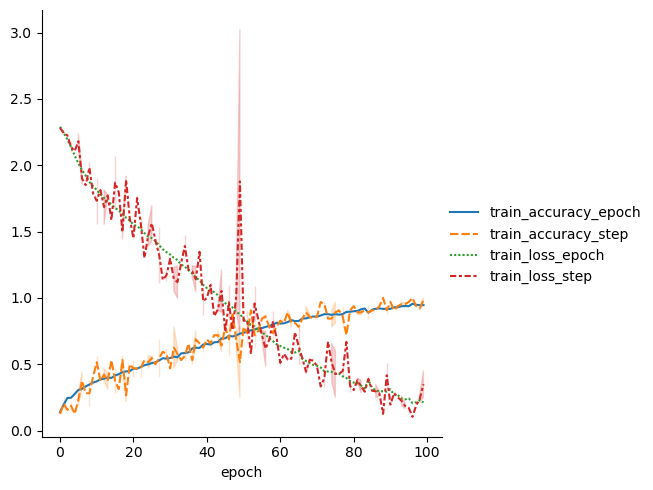

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metrics = pd.read_csv(f"logs/lightning_logs/version_0/metrics.csv")
del metrics["step"]
metrics.set_index("epoch", inplace=True)
sns.relplot(data=metrics, kind="line")
plt.show()

## 5. Evaluation on Test Set

We evaluate the trained model on the test subset to measure its generalisation performance.

In [8]:
model.eval()

total = 0
correct = 0
total_loss = 0.0
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(model.device), labels.to(model.device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

avg_loss = total_loss / len(testloader)
accuracy = 100 * correct / total

print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 1.8541
Test Accuracy: 32.60%


## Summary and Next Steps

**Accomplished:**
- Built a dense neural network for image classification on CIFAR‑10.
- Incorporated **dropout** (p=0.2) after the first hidden layer to regularise the model.
- Trained the network using PyTorch Lightning for 10 epochs (reduced from 100 for demonstration).
- Logged training metrics to CSV and visualised them.
- Evaluated the model on a test subset of 500 images.

**Key Results:**
- Test Loss: **1.8541**
- Test Accuracy: **32.60%**

The model achieved modest accuracy on the test set, which is expected given:
- The small training subset (2,500 images out of 50,000).
- The use of a simple dense network (not convolutional).
- Only 10 epochs of training.

**Key Insights:**
- Dropout is an effective regularisation technique that improves generalisation by randomly dropping neurons during training.
- The hyperparameter `p` controls the dropout rate; typical values are between 0.2 and 0.5.
- Training with dropout may require more epochs to converge because it reduces the capacity of the network during training.
- CIFAR‑10 is challenging for simple dense networks; convolutional architectures (CNNs) are more suitable for image data and would achieve significantly higher accuracy.
- The metrics CSV logging provides a lightweight way to track training progress without external logging services.

**Suggested Next Steps:**
1. **Compare with a model without dropout** – implement a version without dropout and compare training/validation curves to see the effect.
2. **Experiment with different dropout rates** – test `p=0.1`, `0.3`, `0.5` to observe the impact on performance.
3. **Increase training epochs** – train for 50 or 100 epochs to allow the model to converge more fully.
4. **Use the full dataset** – train on all 50,000 training images instead of a subset.
5. **Switch to a convolutional architecture** – replace the dense network with a CNN (e.g., using `nn.Conv2d` and `nn.MaxPool2d`) to achieve much higher accuracy.
6. **Add more hidden layers** – increase depth and observe the effect of dropout.
7. **Save the model checkpoint** – use `torch.save(model.state_dict(), "dropout_model.pt")` to avoid retraining in the future.

**Reflection:**
This notebook provides a practical introduction to dropout regularisation using a simple dense network on CIFAR‑10. Although the dataset is better suited for convolutional architectures, the exercise illustrates the core concept of dropout and its role in preventing overfitting. The modular code using PyTorch Lightning makes it easy to experiment with different regularisation strategies and hyperparameters. The CSV logging provides a lightweight alternative to external logging services, making the notebook self‑contained and reproducible.